# Linear Regression

## House price prediction

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#reading house price file from local system
df = pd.read_csv("D:/Work/Python/Machine Learning/Datasets/house_prices_dataset.csv")

In [3]:
# initial five rows in the dataset
df.head()

,area,price
0,2231.88,558852.17
1,2524.92,632260.29
2,1527.65,382994.25
3,1986.09,497607.86
4,2920.16,730870.84


In [4]:
#Statistics measures of the data
df.describe()

,area,price
count,100.00000,100.000000
mean,2247.97960,562990.340700
std,453.86445,113464.467239
min,1522.16000,381657.070000
25%,1812.84750,454164.525000
50%,2284.15000,571887.305000
75%,2617.72750,655407.227500
max,2995.40000,749686.490000


In [5]:
#information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   area    100 non-null    float64
 1   price   100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


### Explorator Data Analysis

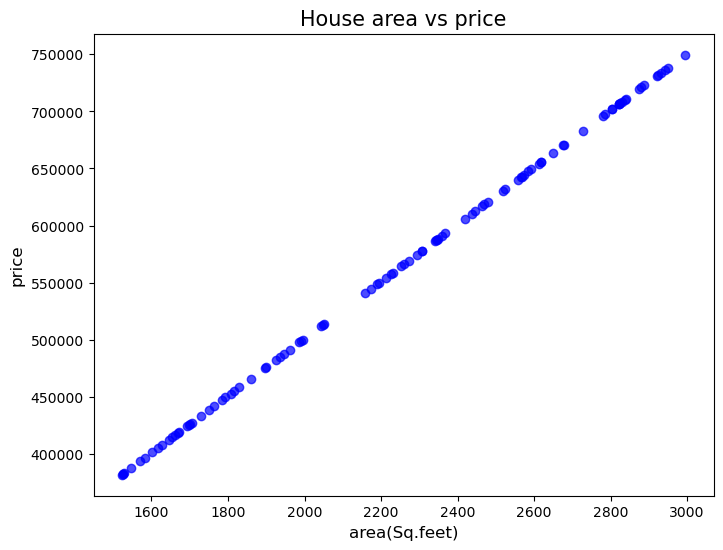

In [6]:
#scatter plot to understand house size and price relationship
plt.figure(figsize=(8,6)) #Set figure size
plt.scatter(df['area'],df['price'], color = 'blue', alpha = 0.7)
plt.title('House area vs price',fontsize = 15)
plt.ylabel('price',fontsize = 12)
plt.xlabel('area(Sq.feet)',fontsize = 12)
plt.show()

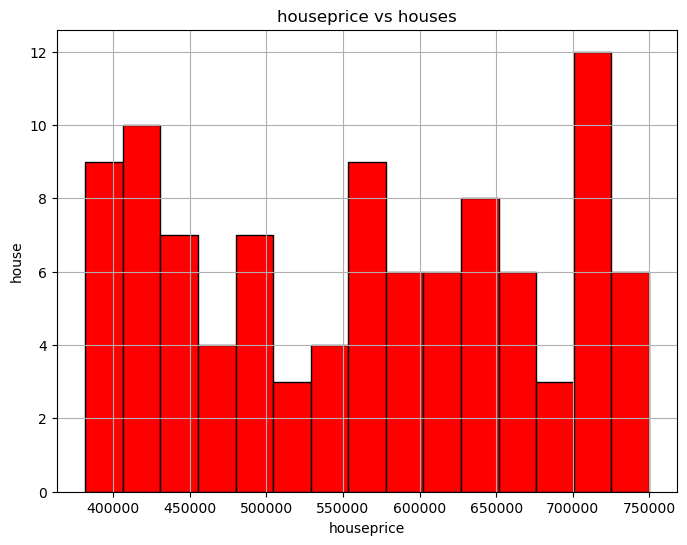

In [7]:
#show the relationship between price and the houses
plt.figure(figsize=(8,6))
plt.hist(df['price'],bins=15,color='red',edgecolor='black')
plt.title('houseprice vs houses')
plt.xlabel('houseprice')
plt.ylabel('house')
plt.grid(True)
plt.show()

In [8]:
X = df[['area']] #this is the feature of the house, this should be in 2D
y = df['price'] #target price to predict the price

In [9]:
#splitting data randomly
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

### Model Training

In [10]:
#training the linear model to predict house price using splitted dat
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [11]:
print(f'Co-efficient (slope m):{model.coef_}') #the best m slope (Sq.ft)
print(f'Intercept (c):{model.intercept_}') #best "C" it's house price. These are minimising the cost function(MSE) in training data

Co-efficient (slope m):[250.00008451]
Intercept (c):1007.1360304440605


In [12]:
#predicted values of the house price
y_pred = model.predict(X_test)
print(f'Predicted price:{y_pred}')

Predicted price:[425667.27959096 706274.8744531  588404.83460598 706557.3745486
 574682.32996695 708517.3752112  696157.37103278 407687.27351264
 427269.7801327  558977.32465772 701724.87291492 702052.37302564
 643019.85306912 438652.28398066 549994.8216211  731047.38282769
 682847.3665332  710852.37600057 418684.77723045 447352.28692179]


### Model Evaluation (Performance Metric Calculation)

In [13]:
#calculating metrics that defines the prediction of the house price.
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(f'Mean Squared Error:{mse:.4f}')
print(f'Root Mean Squared Error:{rmse:.4f}')
print(f'r2 Score:{r2:.8f}')

Mean Squared Error:14614.8219
Root Mean Squared Error:120.8918
r2 Score:0.99999898


### Predicted price Vs Actual Price

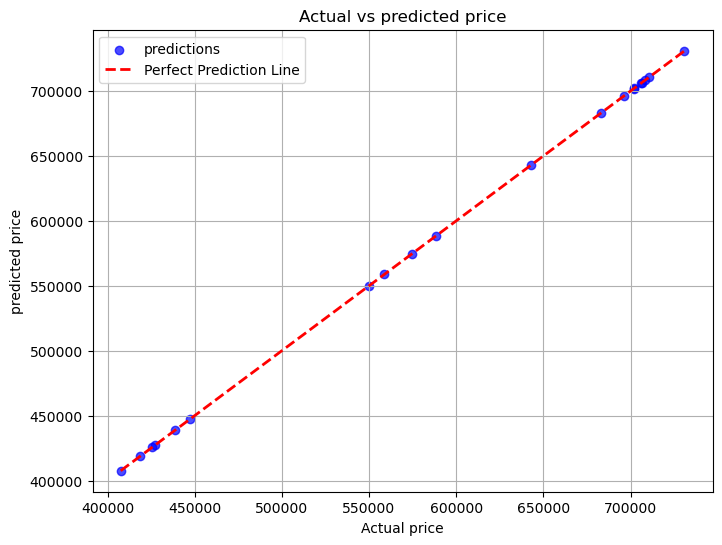

In [14]:
#predicted price vs actual price
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,color='blue',alpha=0.7,label='predictions')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2,label='Perfect Prediction Line')
plt.xlabel('Actual price')
plt.ylabel('predicted price')
plt.title('Actual vs predicted price')
plt.legend()
plt.grid(True)
plt.show()

### Residual Analysis

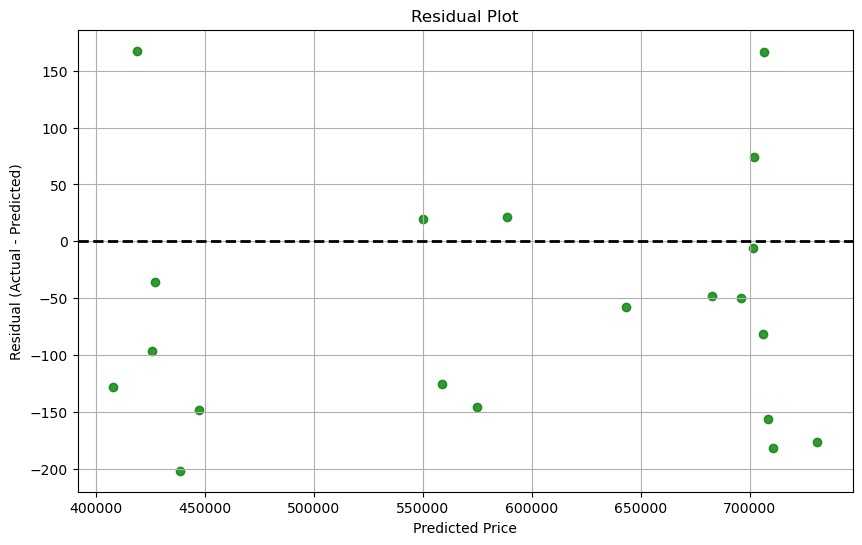

In [15]:
#Residual calculation
residual = y_test - y_pred

# Residual plot
plt.figure(figsize=(10,6))
plt.scatter(y_pred, residual, color='green', alpha=0.8)
plt.axhline(y=0, color='black',linestyle='--', linewidth=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

### Model interpretation & Final Evaluation

In [18]:
# After training the model
print("Model Performance Summary")
print("="*40)
print(f"Intercept (c)     : {model.intercept_:,.2f}")
print(f"Slope (m)         : {model.coef_[0]:,.2f}")
print(f"R² Score (Train)  : {model.score(X_train, y_train):.4f}")
print(f"R² Score (Test)   : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE              : ₹{np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")

Model Performance Summary
Intercept (c)     : 1,007.14
Slope (m)         : 250.00
R² Score (Train)  : 1.0000
R² Score (Test)   : 1.0000
RMSE              : ₹120.89


In [18]:
#Make predictions on new houses
new_area = pd.DataFrame({'area':[1252,1300,2365,1264]})

new_predictions = model.predict(new_area)

for area, price in zip(new_area['area'],new_predictions):
    print(f'Area: {area} sq.ft -> predicted price: ${price:,.2f}')

Area: 1252 sq.ft -> predicted price: $314,007.24
Area: 1300 sq.ft -> predicted price: $326,007.25
Area: 2365 sq.ft -> predicted price: $592,257.34
Area: 1264 sq.ft -> predicted price: $317,007.24


### Business Insights

* On average, our prediction is off by $121. Area explains 99% of the variation in house prices.
  
* Eg: If the average house price is 2000 dollar, 121 dollar error may be acceptable for initial screening but not for final pricing.

In [ ]:
# for deployment
# import joblib

# save model
#joblib.dump(model, 'house_prediction_model.pkl')

#loaded_model = joblib.load('house_price_model.pkl')